In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_parquet("../data/processed/states_2023.parquet")
print(f"{len(df):,} rows  |  {df['round'].nunique()} races  |  {df['driver'].nunique()} drivers")

23,259 rows  |  22 races  |  22 drivers


## 1. First 10 rows

In [2]:
STATE_COLS = ["event_name", "driver", "lap_number", "compound", "tire_age_bin", "position_bin", "race_state", "gap_bin", "action", "state_tuple"]
df[STATE_COLS].head(10)

,event_name,driver,lap_number,compound,tire_age_bin,position_bin,race_state,gap_bin,action,state_tuple
0,Bahrain Grand Prix,VER,1,SOFT,0,0,green,0,0,1|SOFT|0|0|green|0
1,Bahrain Grand Prix,VER,2,SOFT,0,0,green,0,0,2|SOFT|0|0|green|0
2,Bahrain Grand Prix,VER,3,SOFT,1,0,green,0,0,3|SOFT|1|0|green|0
3,Bahrain Grand Prix,VER,4,SOFT,1,0,green,0,0,4|SOFT|1|0|green|0
4,Bahrain Grand Prix,VER,5,SOFT,1,0,green,0,0,5|SOFT|1|0|green|0
5,Bahrain Grand Prix,VER,6,SOFT,1,0,green,0,0,6|SOFT|1|0|green|0
6,Bahrain Grand Prix,VER,7,SOFT,1,0,green,0,0,7|SOFT|1|0|green|0
7,Bahrain Grand Prix,VER,8,SOFT,2,0,green,0,0,8|SOFT|2|0|green|0
8,Bahrain Grand Prix,VER,9,SOFT,2,0,green,0,0,9|SOFT|2|0|green|0
9,Bahrain Grand Prix,VER,10,SOFT,2,0,green,0,0,10|SOFT|2|0|green|0


## 2. Distribution of each state variable

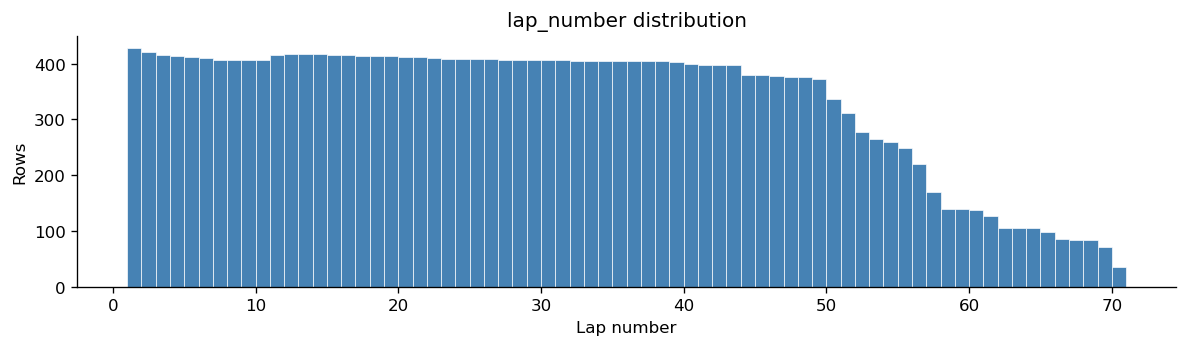

count    23259.000000
mean        29.382390
std         17.419536
min          1.000000
25%         15.000000
50%         29.000000
75%         43.000000
max         70.000000


In [3]:
# Lap number histogram
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df["lap_number"], bins=range(1, df["lap_number"].max() + 2), color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Lap number")
ax.set_ylabel("Rows")
ax.set_title("lap_number distribution")
plt.tight_layout()
plt.show()

print(df["lap_number"].describe().to_string())

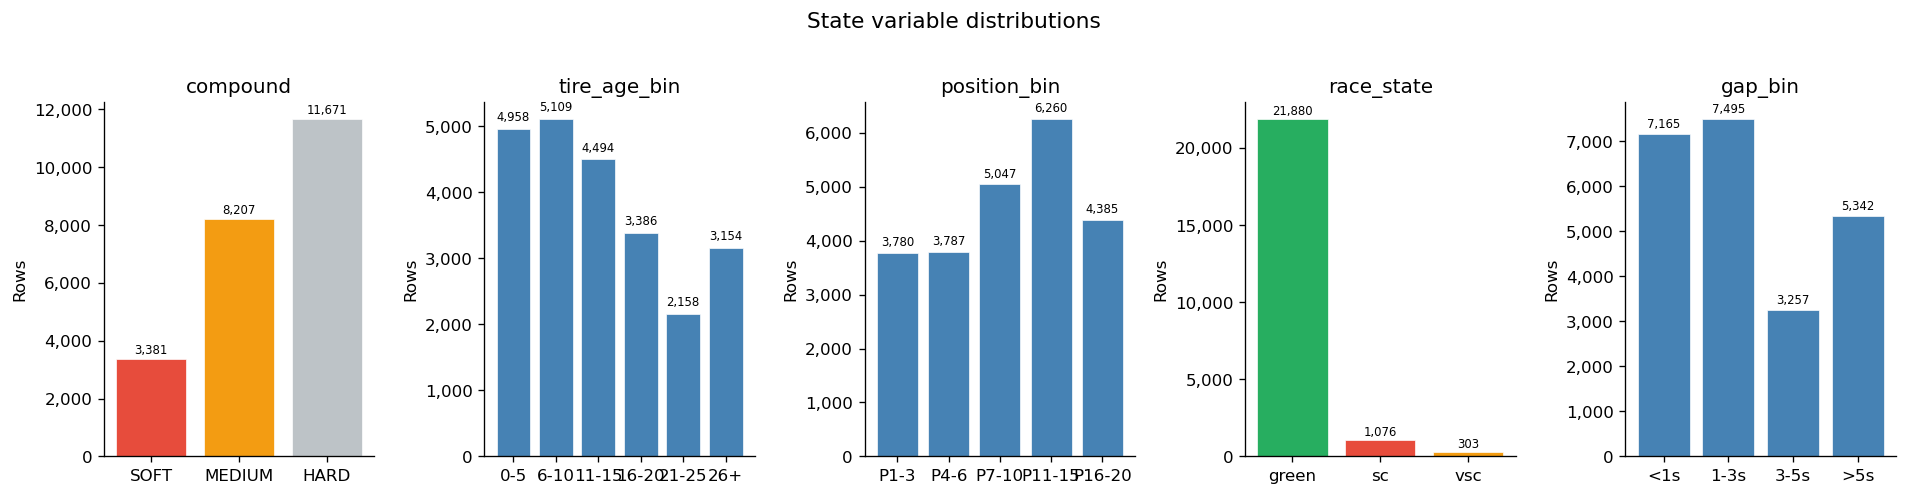


compound:
      SOFT:  3,381  (14.5%)
    MEDIUM:  8,207  (35.3%)
      HARD: 11,671  (50.2%)

tire_age_bin:
       0-5:  4,958  (21.3%)
      6-10:  5,109  (22.0%)
     11-15:  4,494  (19.3%)
     16-20:  3,386  (14.6%)
     21-25:  2,158  (9.3%)
       26+:  3,154  (13.6%)

position_bin:
      P1-3:  3,780  (16.3%)
      P4-6:  3,787  (16.3%)
     P7-10:  5,047  (21.7%)
    P11-15:  6,260  (26.9%)
    P16-20:  4,385  (18.9%)

race_state:
     green: 21,880  (94.1%)
        sc:  1,076  (4.6%)
       vsc:    303  (1.3%)

gap_bin:
       <1s:  7,165  (30.8%)
      1-3s:  7,495  (32.2%)
      3-5s:  3,257  (14.0%)
       >5s:  5,342  (23.0%)


In [4]:
# Categorical / binned state variables
CAT_VARS = [
    ("compound",     ["SOFT", "MEDIUM", "HARD"]),
    ("tire_age_bin", [0, 1, 2, 3, 4, 5]),
    ("position_bin", [0, 1, 2, 3, 4]),
    ("race_state",   ["green", "sc", "vsc"]),
    ("gap_bin",      [0, 1, 2, 3]),
]

BIN_LABELS = {
    "tire_age_bin": {0: "0-5",  1: "6-10", 2: "11-15", 3: "16-20", 4: "21-25", 5: "26+"},
    "position_bin": {0: "P1-3", 1: "P4-6", 2: "P7-10", 3: "P11-15", 4: "P16-20"},
    "gap_bin":      {0: "<1s",  1: "1-3s", 2: "3-5s",  3: ">5s"},
}

fig, axes = plt.subplots(1, len(CAT_VARS), figsize=(16, 4))

COLORS = {"compound": ["#e74c3c", "#f39c12", "#bdc3c7"],
          "race_state": ["#27ae60", "#e74c3c", "#f39c12"]}

for ax, (col, order) in zip(axes, CAT_VARS):
    counts = df[col].value_counts().reindex(order, fill_value=0)
    labels = [BIN_LABELS.get(col, {}).get(v, str(v)) for v in counts.index]
    colors = COLORS.get(col, ["steelblue"] * len(order))
    bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel("Rows")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                f"{val:,}", ha="center", va="bottom", fontsize=7)

plt.suptitle("State variable distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Print value counts
for col, order in CAT_VARS:
    counts = df[col].value_counts().reindex(order, fill_value=0)
    print(f"\n{col}:")
    for k, v in counts.items():
        label = BIN_LABELS.get(col, {}).get(k, str(k))
        print(f"  {label:>8}: {v:>6,}  ({v/len(df):.1%})")

## 3. Pit vs stay-out action split

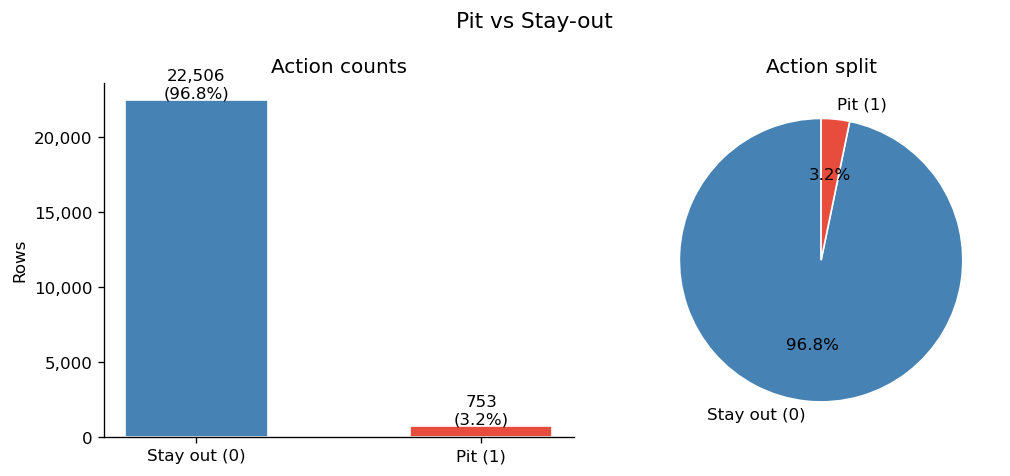

  Stay out (0): 22,506  (96.8%)
  Pit (1): 753  (3.2%)


In [5]:
counts = df["action"].value_counts().sort_index()
labels = ["Stay out (0)", "Pit (1)"]
total  = len(df)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=["steelblue", "#e74c3c"], width=0.5, edgecolor="white")
axes[0].set_ylabel("Rows")
axes[0].set_title("Action counts")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f"{v:,}\n({v/total:.1%})", ha="center", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=["steelblue", "#e74c3c"],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Action split")

plt.suptitle("Pit vs Stay-out", fontsize=13)
plt.tight_layout()
plt.show()

for label, (val, cnt) in zip(labels, counts.items()):
    print(f"  {label}: {cnt:,}  ({cnt/total:.1%})")

## 4. Pit rate by compound and race_state

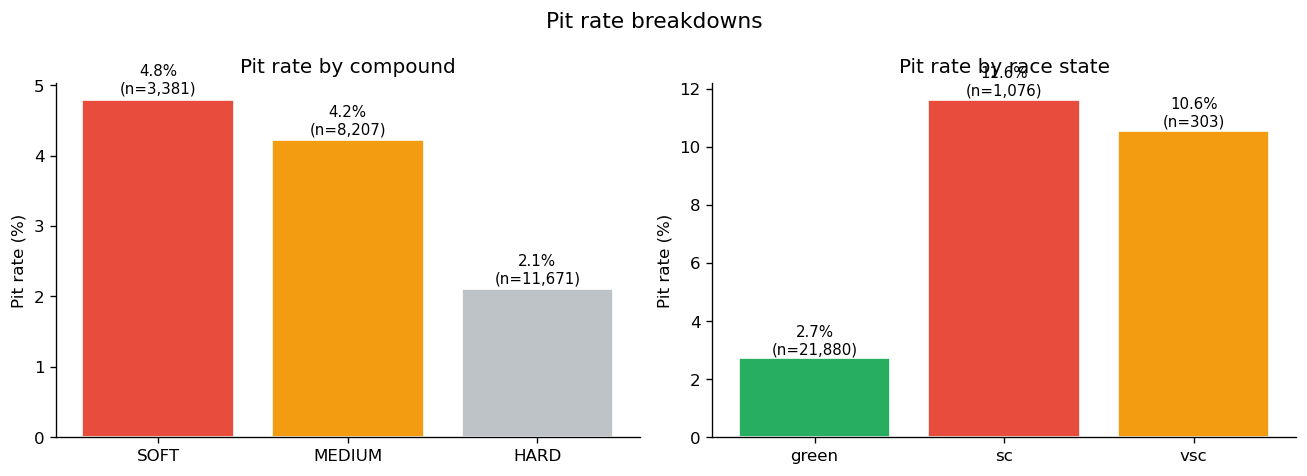

By compound:
          total  pits  pit_rate
compound                       
SOFT       3381   162  0.047915
MEDIUM     8207   346  0.042159
HARD      11671   245  0.020992

By race state:
            total  pits  pit_rate
race_state                       
green       21880   596  0.027239
sc           1076   125  0.116171
vsc           303    32  0.105611


In [6]:
def pit_rate_table(df, col, order):
    tbl = (
        df.groupby(col)["action"]
        .agg(total="count", pits="sum")
        .reindex(order)
    )
    tbl["pit_rate"] = tbl["pits"] / tbl["total"]
    return tbl

by_compound    = pit_rate_table(df, "compound",   ["SOFT", "MEDIUM", "HARD"])
by_race_state  = pit_rate_table(df, "race_state", ["green", "sc", "vsc"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# By compound
comp_colors = ["#e74c3c", "#f39c12", "#bdc3c7"]
bars = axes[0].bar(by_compound.index, by_compound["pit_rate"] * 100,
                   color=comp_colors, edgecolor="white")
axes[0].set_ylabel("Pit rate (%)")
axes[0].set_title("Pit rate by compound")
for bar, (_, row) in zip(bars, by_compound.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{row.pit_rate:.1%}\n(n={int(row.total):,})",
                 ha="center", va="bottom", fontsize=9)

# By race state
state_colors = ["#27ae60", "#e74c3c", "#f39c12"]
bars = axes[1].bar(by_race_state.index, by_race_state["pit_rate"] * 100,
                   color=state_colors, edgecolor="white")
axes[1].set_ylabel("Pit rate (%)")
axes[1].set_title("Pit rate by race state")
for bar, (_, row) in zip(bars, by_race_state.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{row.pit_rate:.1%}\n(n={int(row.total):,})",
                 ha="center", va="bottom", fontsize=9)

plt.suptitle("Pit rate breakdowns", fontsize=13)
plt.tight_layout()
plt.show()

print("By compound:")
print(by_compound.to_string())
print("\nBy race state:")
print(by_race_state.to_string())

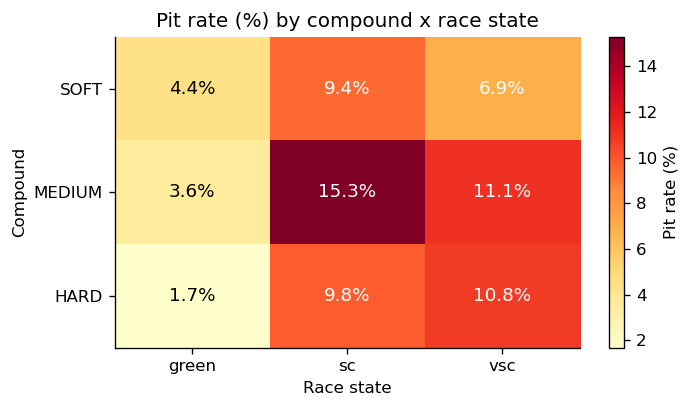

race_state  green      sc     vsc
compound                         
SOFT        4.41%   9.43%   6.90%
MEDIUM      3.56%  15.28%  11.11%
HARD        1.67%   9.80%  10.79%


In [7]:
# Combined heatmap: pit rate by compound x race_state
pivot = (
    df.groupby(["compound", "race_state"])["action"]
    .agg(pits="sum", total="count")
    .assign(pit_rate=lambda x: x["pits"] / x["total"])
    ["pit_rate"]
    .unstack("race_state")
    .reindex(index=["SOFT", "MEDIUM", "HARD"],
             columns=["green", "sc", "vsc"])
)

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(pivot.values * 100, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Pit rate (%)")
ax.set_xticks(range(3)); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(3)); ax.set_yticklabels(pivot.index)
ax.set_xlabel("Race state")
ax.set_ylabel("Compound")
ax.set_title("Pit rate (%) by compound x race state")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1%}" if pd.notna(val) else "n/a",
                ha="center", va="center", fontsize=11,
                color="white" if val > 0.05 else "black")

plt.tight_layout()
plt.show()

print(pivot.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "n/a").to_string())

## 5. Tyre degradation curves

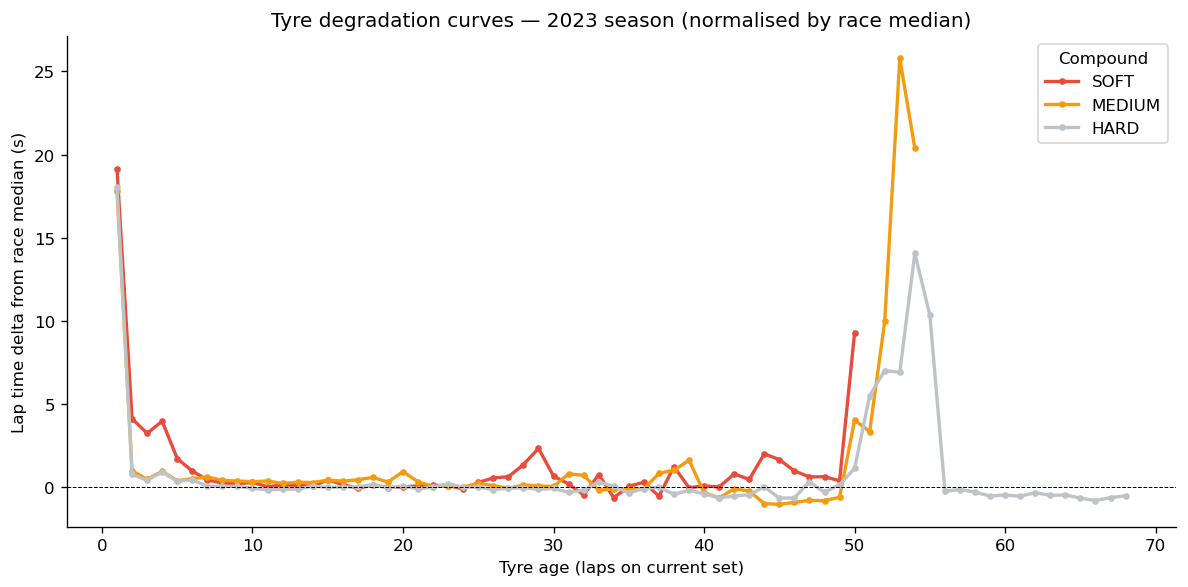

Laps used: 21,310  (filtered from 24,431 total)
  SOFT: 3,009 laps
  MEDIUM: 7,350 laps
  HARD: 10,951 laps


In [8]:
laps = pd.read_parquet("../data/processed/laps_2023.parquet")

mask = (
    ~laps["safety_car_status"].isin(["sc", "vsc"])
    & laps["lap_time_s"].between(70, 120)
    & laps["compound"].isin(["SOFT", "MEDIUM", "HARD"])
)
laps_clean = laps[mask].copy()

race_medians = laps_clean.groupby("round")["lap_time_s"].median().rename("race_median")
laps_clean = laps_clean.join(race_medians, on="round")
laps_clean["lap_time_norm"] = laps_clean["lap_time_s"] - laps_clean["race_median"]

deg = (
    laps_clean.groupby(["compound", "tyre_age"])["lap_time_norm"]
    .mean()
    .reset_index()
)

COMPOUND_COLORS = {"SOFT": "#e74c3c", "MEDIUM": "#f39c12", "HARD": "#bdc3c7"}

fig, ax = plt.subplots(figsize=(10, 5))

for compound, color in COMPOUND_COLORS.items():
    sub = deg[deg["compound"] == compound].sort_values("tyre_age")
    ax.plot(sub["tyre_age"].to_numpy(), sub["lap_time_norm"].to_numpy(), color=color, label=compound, linewidth=2, marker="o", markersize=3)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("Tyre age (laps on current set)")
ax.set_ylabel("Lap time delta from race median (s)")
ax.set_title("Tyre degradation curves — 2023 season (normalised by race median)")
ax.legend(title="Compound")
plt.tight_layout()
plt.show()

print(f"Laps used: {len(laps_clean):,}  (filtered from {len(laps):,} total)")
for compound in ["SOFT", "MEDIUM", "HARD"]:
    n = (laps_clean["compound"] == compound).sum()
    print(f"  {compound}: {n:,} laps")